In [1]:
import numpy as np
import healpy as hp
import cmocean as cmo
import matplotlib.pyplot as plt

import skykit as sk
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial',
                               'Lucida Grande']

In [2]:
map_hpx = hp.read_map('HFI_353GHz_IntDR3_NoCMB_NoPS_5arcmin_map-zeroadjust-step3.fits', field=0)

In [3]:
map_patches = sk.healpix2tiles(map_hpx, 2048, 256, 64, margin_method='geometric')


In [4]:
map_patches_topo = sk.healpix2tiles(map_hpx, 2048, 256, 64, margin_method='topological')

In [5]:
map_from_patches = sk.tiles2healpix(map_patches)

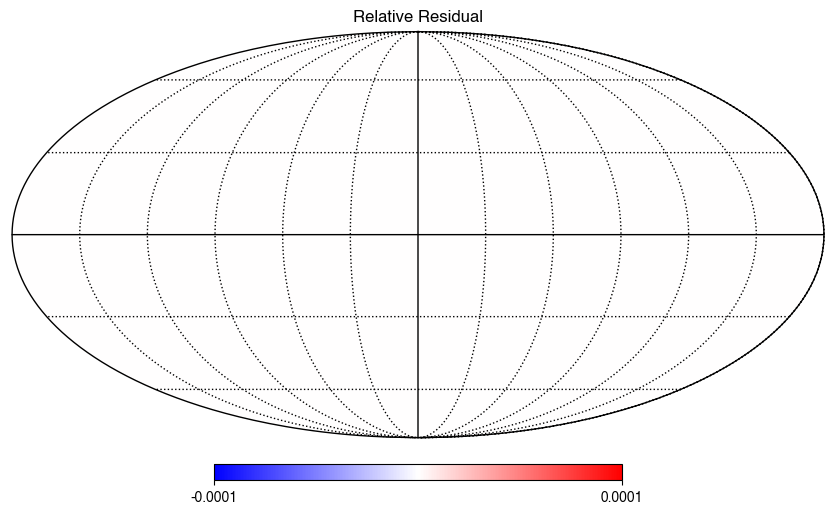

In [6]:
hp.mollview((map_hpx - map_from_patches)/map_hpx, cmap='bwr', min=-1e-4, max=1e-4, title="Relative Residual")
hp.graticule(dpar=30., dmer=30)

In [7]:
lon = 280.
lat = 90.
f, x, y = map_patches.tile_containing(lon, lat)

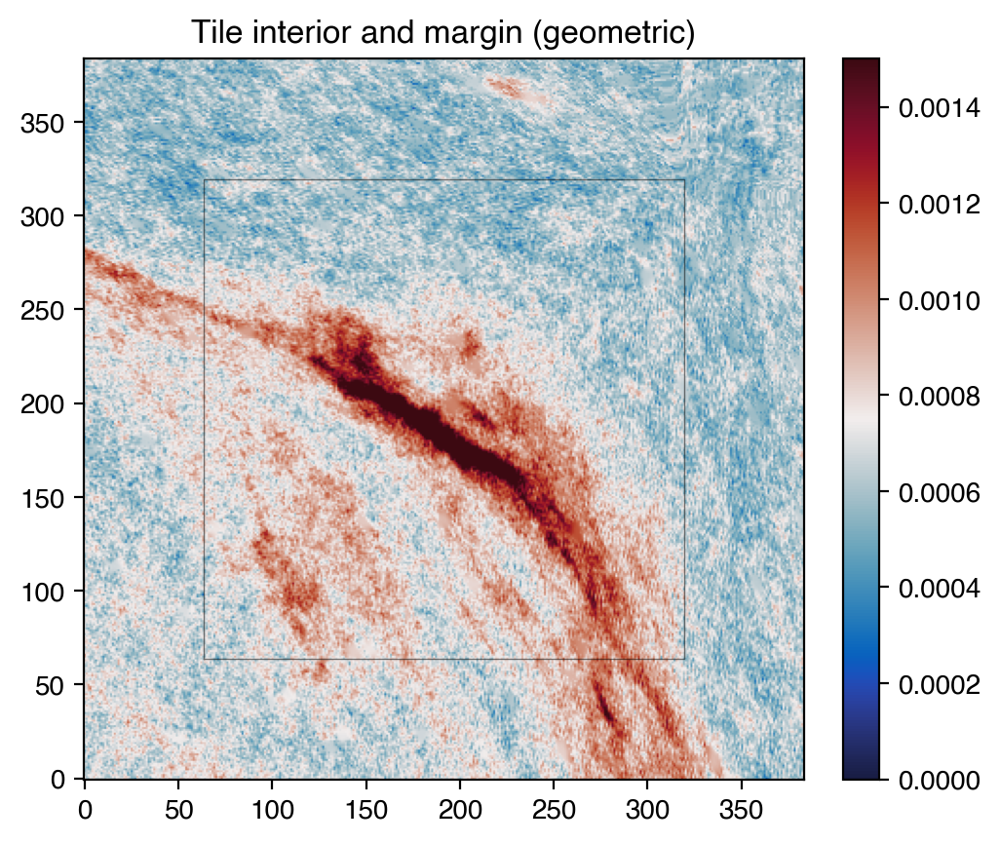

In [8]:
fig = sk.plot_tile_flat(
    map_patches, f, x, y, dpi=200,
    title='Tile interior and margin (geometric)',
    cmap=cmo.cm.balance, vmin=0, vmax=1.5e-3,
)
fig.savefig('../docs/figures/dust_north-pole-tile_geometric.png')

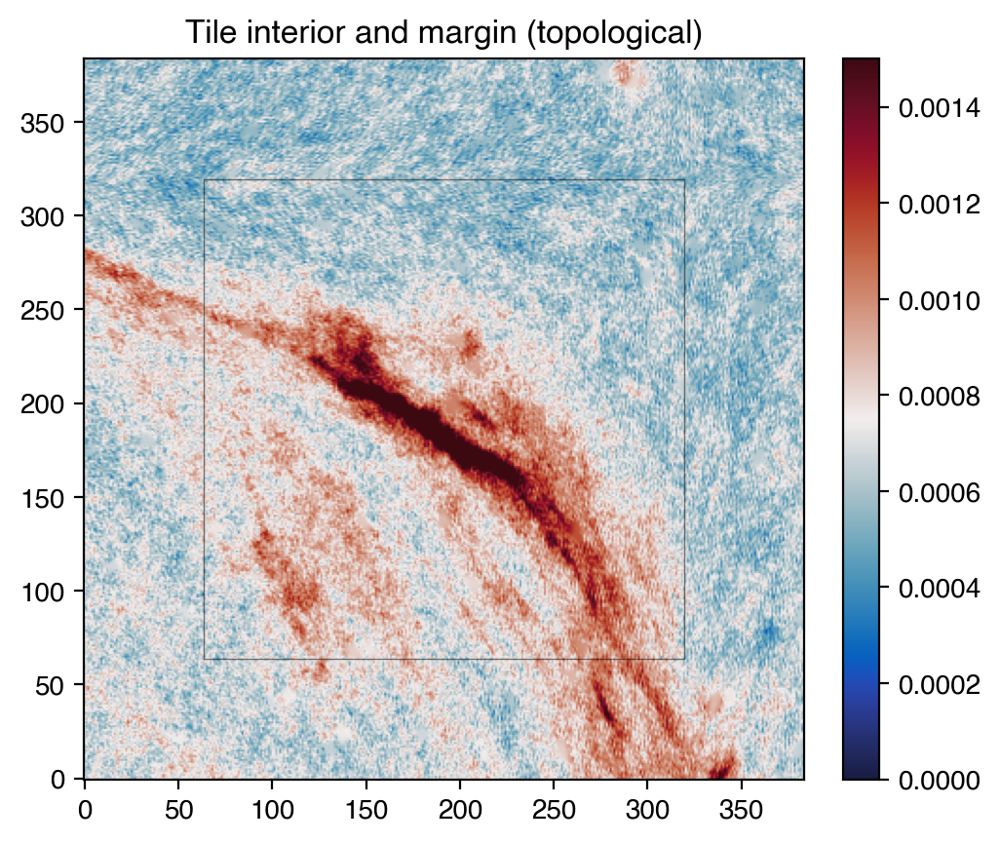

In [9]:
fig = sk.plot_tile_flat(
    map_patches_topo, f, x, y, dpi=200,
    title='Tile interior and margin (topological)',
    cmap=cmo.cm.balance, vmin=0, vmax=1.5e-3,
)
fig.savefig('../docs/figures/dust_north-pole-tile_topological.png')

/Users/shamik/opt/cmbenv/mac-0.0.1/conda/lib/python3.12/site-packages/healpy/visufunc.py:468: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(5.8, 6.4))


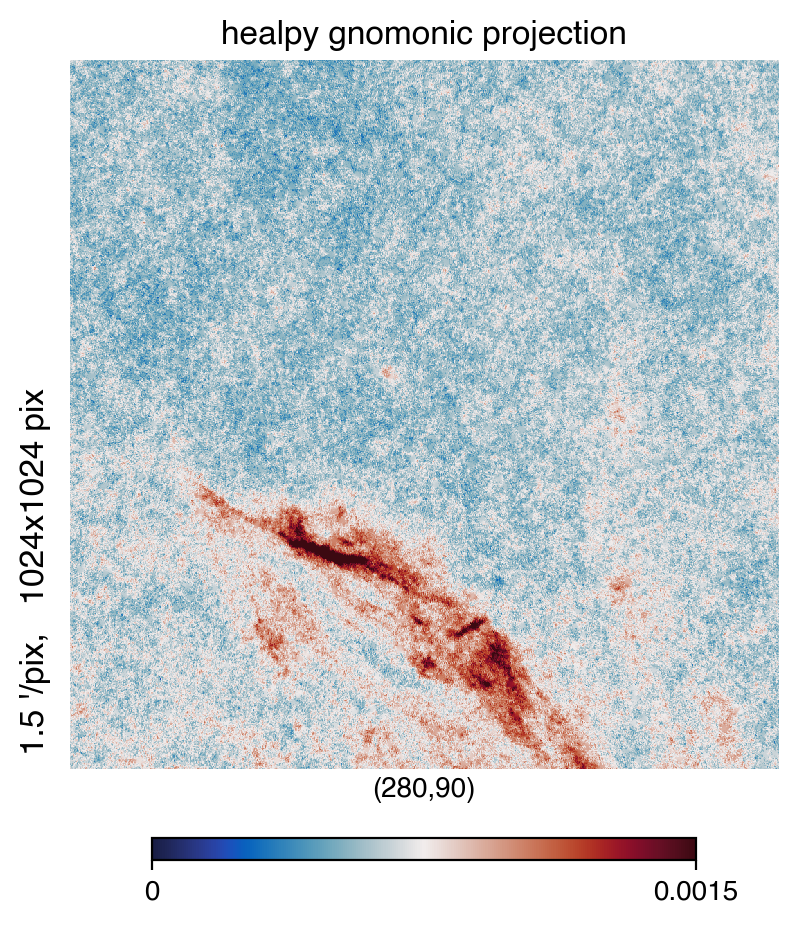

In [10]:
fig = plt.figure(dpi=200)
hp.gnomview(map_hpx, fig=fig.number, rot=(280,90,0), reso=1.5, xsize=1024, cmap=cmo.cm.balance, min=0, max=1.5e-3, title="healpy gnomonic projection")

In [11]:
lon = 80.
lat = -90.
f, x, y = map_patches.tile_containing(lon, lat)
print(f, x, y)

8 0 0


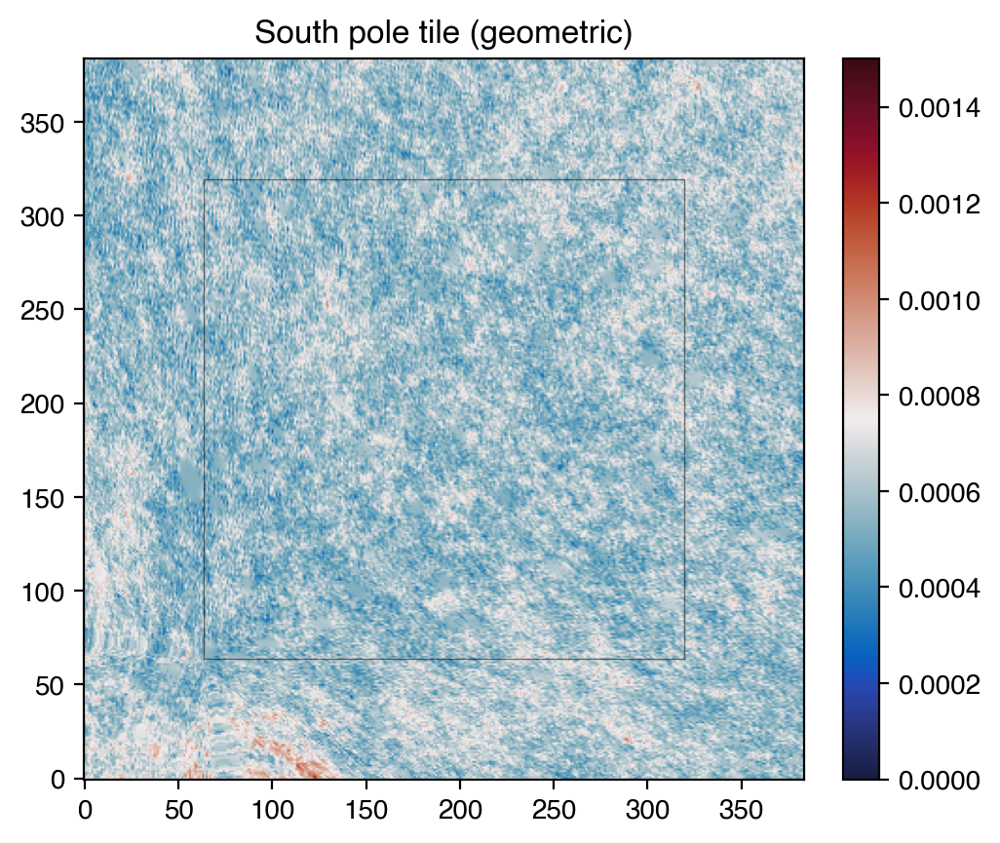

In [12]:
fig = sk.plot_tile_flat(
    map_patches, f, x, y, dpi=200,
    title='South pole tile (geometric)',
    cmap=cmo.cm.balance, vmin=0, vmax=1.5e-3,
)

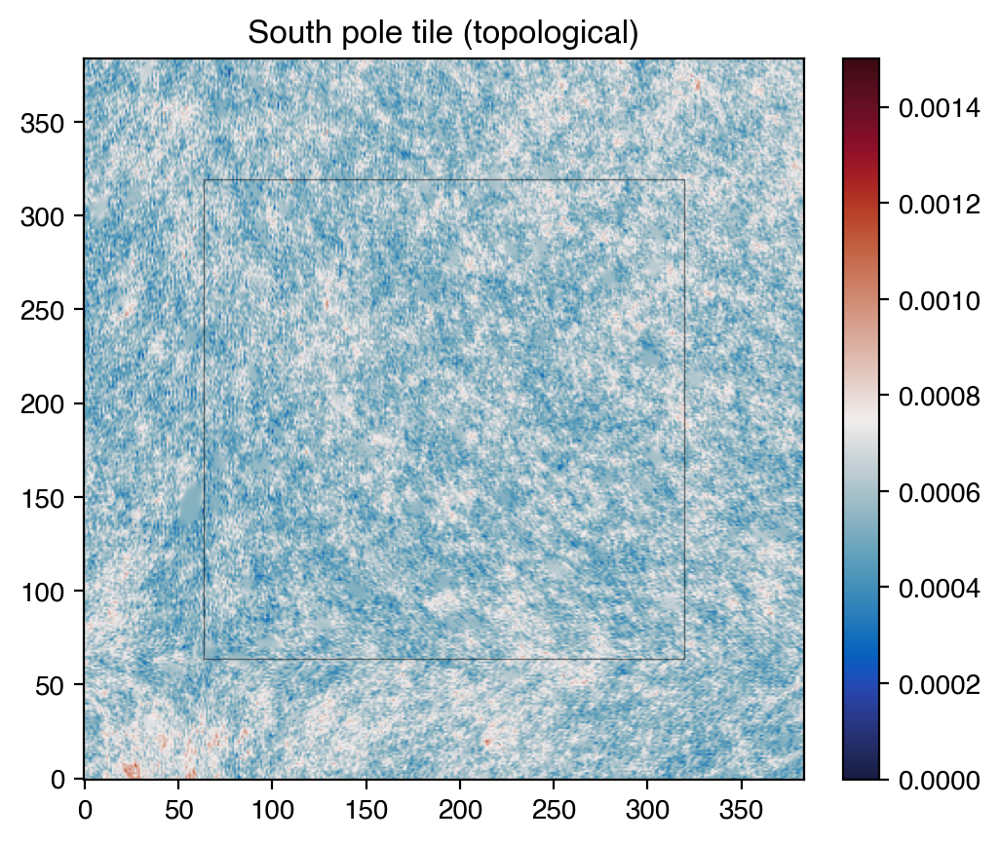

In [13]:
fig = sk.plot_tile_flat(
    map_patches_topo, f, x, y, dpi=200,
    title='South pole tile (topological)',
    cmap=cmo.cm.balance, vmin=0, vmax=1.5e-3,
)

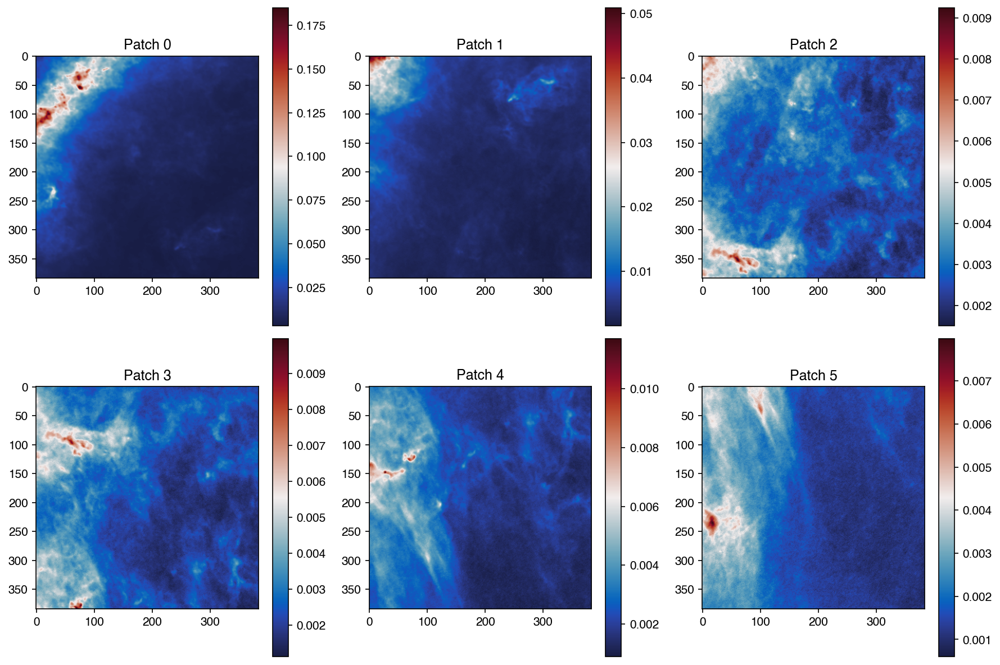

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=150)

for i, ax in enumerate(axes.flat):
    im = ax.imshow(map_patches.data[i, :, :], cmap=cmo.cm.balance)
    ax.set_title(f'Patch {i}')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

/var/folders/yy/4xf19n1n7_31nlkz7lv1wh980000gn/T/ipykernel_39957/320426828.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


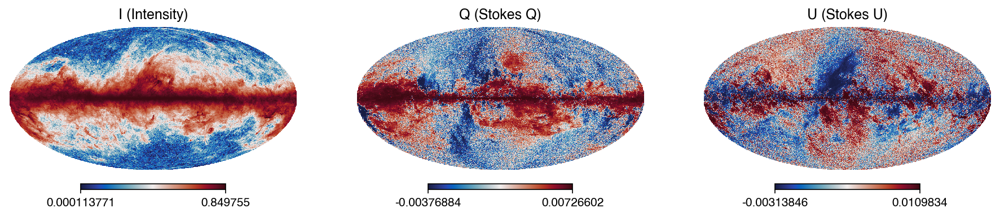

In [16]:
hpx_iqu_map = hp.read_map('/Users/shamik/Documents/Work/dust_GNILC/data/pr3/HFI_SkyMap_353-psb_2048_R3.01_full-evenring.fits', field=[0, 1, 2])
hpx_iqu_map[hpx_iqu_map == hp.UNSEEN] = 0.0
temp = hp.read_map('/Users/shamik/Documents/Work/dust_GNILC/data/pr3/HFI_SkyMap_353-psb_2048_R3.01_full-oddring.fits', field=[0, 1, 2])
temp[temp == hp.UNSEEN] = 0.0
hpx_iqu_map += temp

del temp

hpx_iqu_map /= 2.
hpx_iqu_map = hp.smoothing(hpx_iqu_map, fwhm=np.radians(7.5/60.), lmax=4000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=150)
titles = ['I (Intensity)', 'Q (Stokes Q)', 'U (Stokes U)']
for i, (title, ax) in enumerate(zip(titles, axes)):
    plt.sca(ax)
    hp.mollview(hpx_iqu_map[i], title=title, cmap=cmo.cm.balance, hold=True,norm='hist')

plt.tight_layout()
plt.show()

In [17]:
qu_patches = sk.healpix2tiles(hpx_iqu_map[1:3], 2048, 256, 128, pol=True)

In [18]:
lon = 280.
lat = 90.
f, x, y = qu_patches.tile_containing(lon, lat)
print(f,x,y)

3 7 7


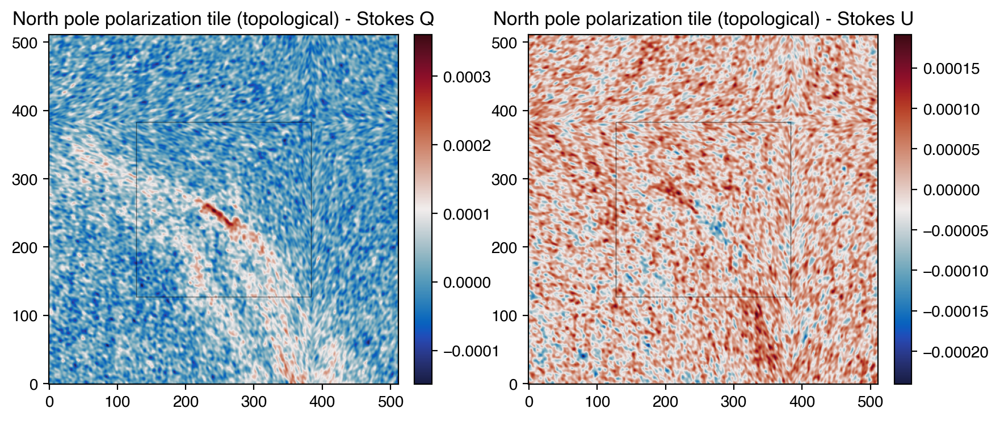

In [19]:
fig = sk.plot_tile_flat(
    qu_patches, f, x, y, dpi=200,
    title='North pole polarization tile (topological)', cmap=cmo.cm.balance,
)
fig.savefig('../docs/figures/pol-dust_north-pole-tile_topological.png')

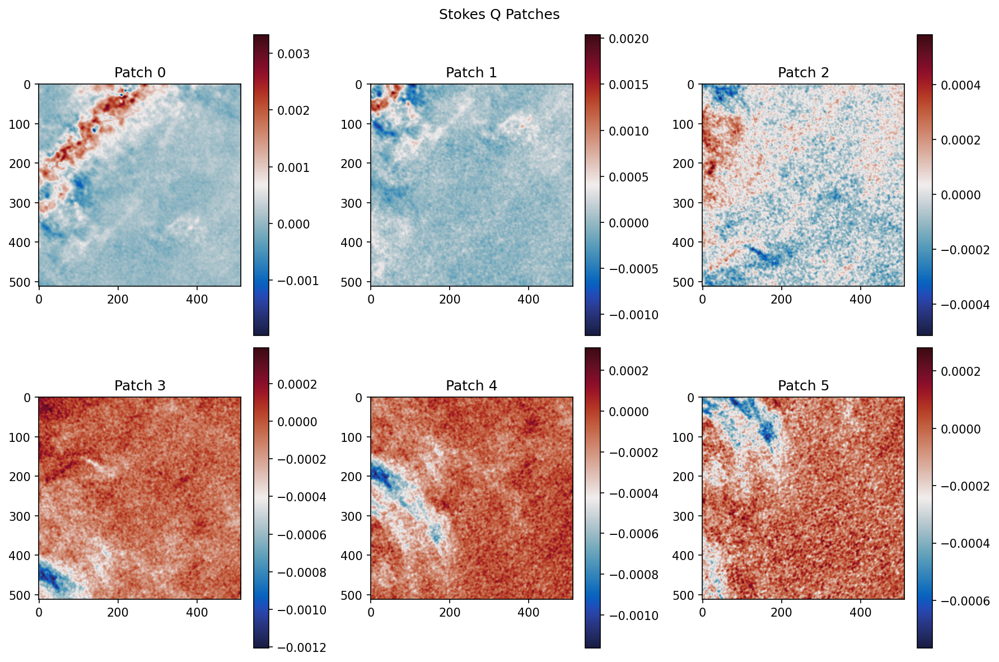

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=150)

for i, ax in enumerate(axes.flat):
    im = ax.imshow(qu_patches.data[i, 0, :, :], cmap=cmo.cm.balance)
    ax.set_title(f'Patch {i}')
    plt.colorbar(im, ax=ax)

plt.suptitle('Stokes Q Patches')
plt.tight_layout()
plt.show()

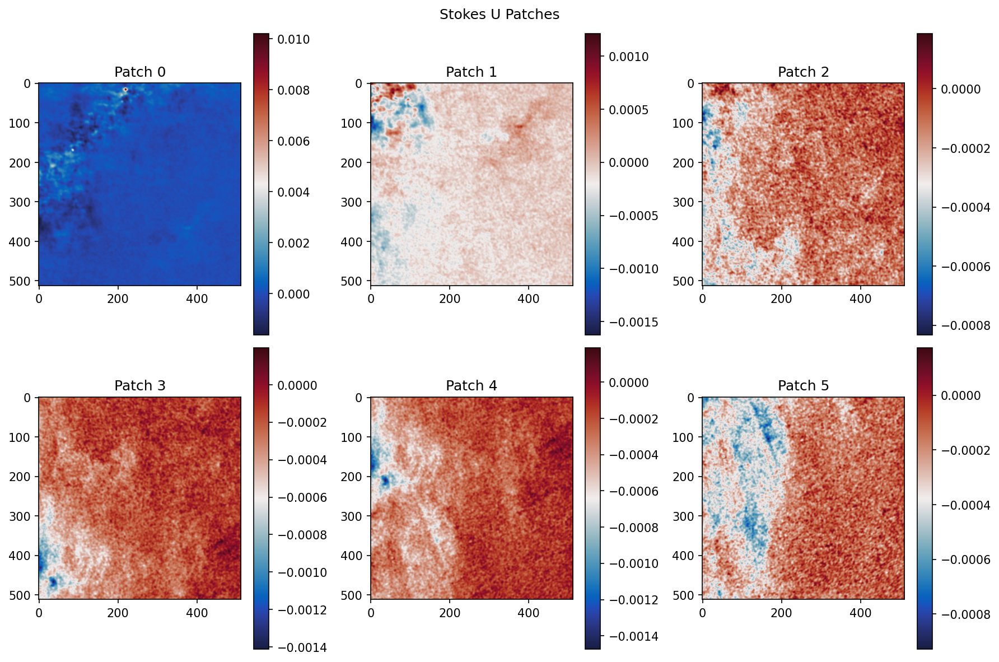

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=150)

for i, ax in enumerate(axes.flat):
    im = ax.imshow(qu_patches.data[i, 1, :, :], cmap=cmo.cm.balance)
    ax.set_title(f'Patch {i}')
    plt.colorbar(im, ax=ax)

plt.suptitle('Stokes U Patches')
plt.tight_layout()
plt.show()

In [ ]:
qu_map_from_patches = sk.tiles2healpix(qu_patches)

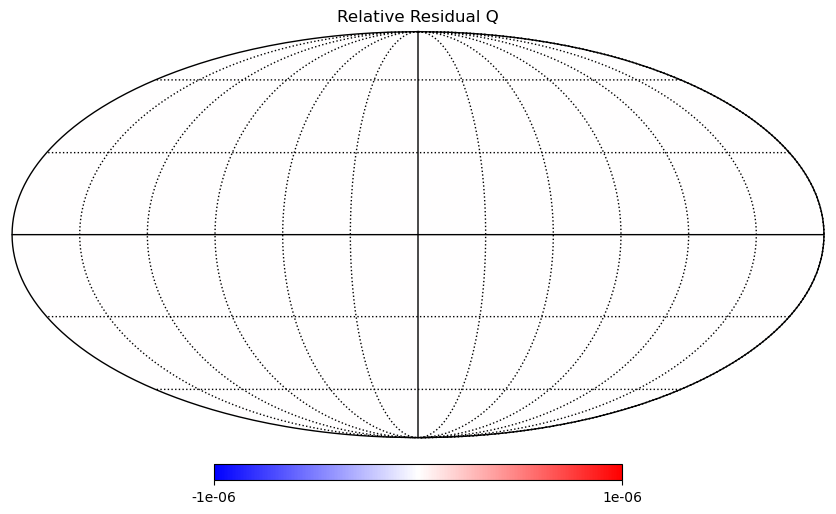

In [23]:
hp.mollview((hpx_iqu_map[1] - qu_map_from_patches[0])/hpx_iqu_map[1], cmap='bwr', min=-1e-6, max=1e-6, title="Relative Residual Q")
hp.graticule(dpar=30., dmer=30)

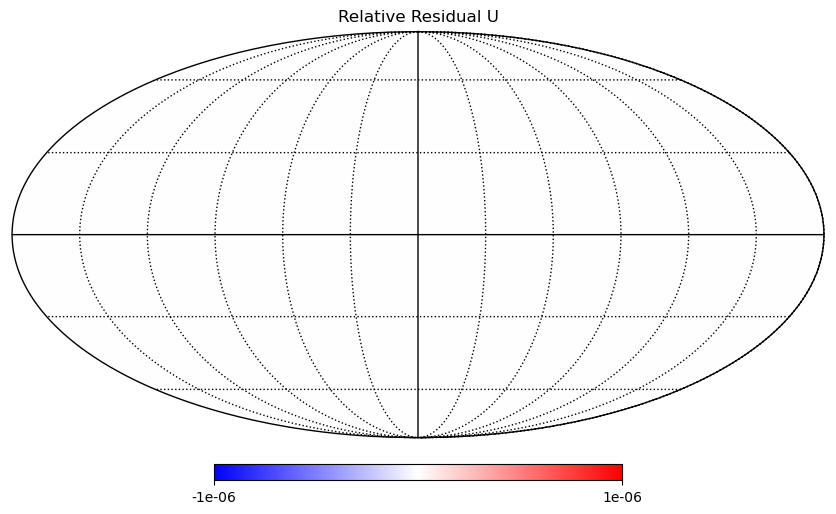

In [20]:
hp.mollview((hpx_iqu_map[2] - qu_map_from_patches[1])/hpx_iqu_map[2], cmap='bwr', min=-1e-6, max=1e-6, title="Relative Residual U")
hp.graticule(dpar=30., dmer=30)